In [ ]:
import torch
import torchvision.transforms as T
import cv2
import numpy as np

In [ ]:
def post_process(seg_map, min_area=500):
    out = np.zeros_like(seg_map)
    unique_classes = np.unique(seg_map)

    for cls in unique_classes:
        mask = (seg_map == cls).astype(np.uint8)
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask)

        for label in range(1, num_labels):  # Skip background
            area = stats[label, cv2.CC_STAT_AREA]
            if area >= min_area:
                out[labels == label] = cls

    return out

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

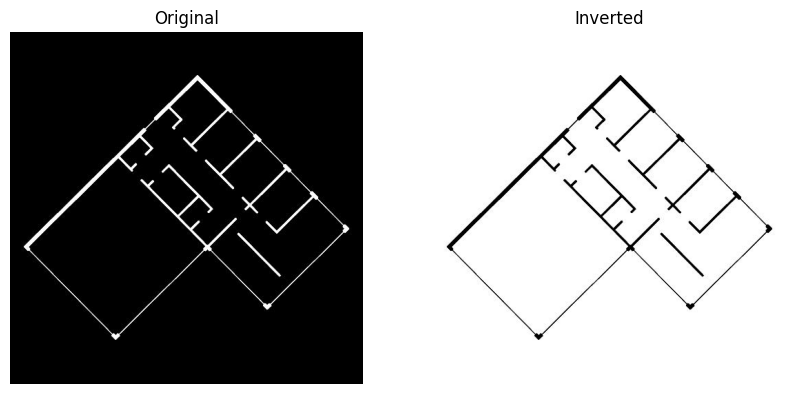

In [ ]:
import matplotlib.pyplot as plt

test_img_path = '/content/floorplan_2.jpg'  # update path
orig = cv2.cvtColor(cv2.imread(test_img_path), cv2.COLOR_BGR2RGB)
H0, W0 = orig.shape[:2]
# ---- new inversion block ----
# convert to gray, invert, then back to 3‑channel RGB
orig_gray = cv2.cvtColor(orig, cv2.COLOR_RGB2GRAY)
inv_gray  = cv2.bitwise_not(orig_gray)
orig_inv  = cv2.cvtColor(inv_gray, cv2.COLOR_GRAY2RGB)
# ---- end inversion block ----

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Original")
plt.axis("off")
plt.imshow(orig)
plt.subplot(1,2,2)
plt.title("Inverted")
plt.axis("off")
plt.imshow(orig_inv)
plt.show()

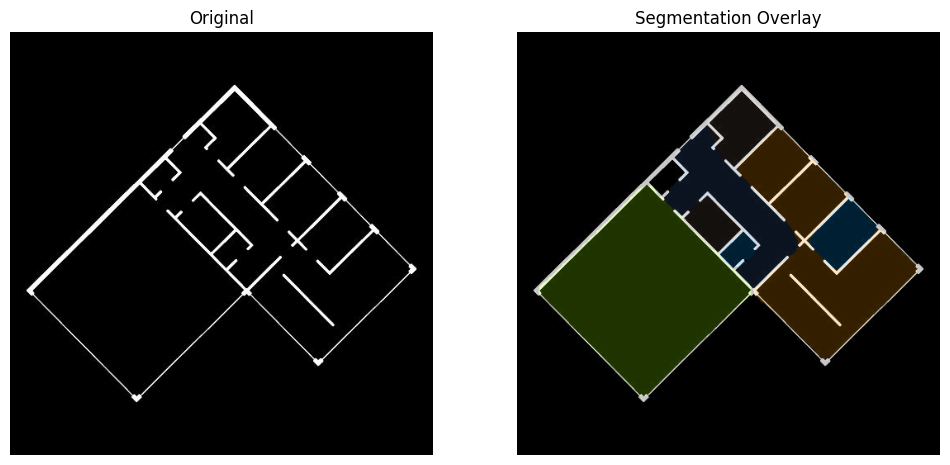

In [ ]:
import os
import cv2
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet50
from PIL import Image
import matplotlib.pyplot as plt

# Define the color map used during training
color_maps = np.array([
    [0, 0, 0],         # background
    [255, 154, 0],     # bedroom/orange
    [50, 99, 155],     # hallway/purple
    [0, 155, 255],     # blue/bathroom
    [155, 255, 0],     # yellow/living
    [100, 80, 71]      # brown/empty-room
], dtype=np.uint8)

# Function to perform post-processing (removing small connected components)
def post_process(seg_map, min_area=500):
    out = np.zeros_like(seg_map)
    unique_classes = np.unique(seg_map)

    for cls in unique_classes:
        mask = (seg_map == cls).astype(np.uint8)
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask)

        for label in range(1, num_labels):  # Skip background
            area = stats[label, cv2.CC_STAT_AREA]
            if area >= min_area:
                out[labels == label] = cls

    return out

# Set the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Define the number of classes
NUM_CLASSES = len(color_maps)

# Load the trained model
model = deeplabv3_resnet50(pretrained_backbone=False, num_classes=NUM_CLASSES) # pretrained_backbone=False as we load a trained model state
model.load_state_dict(torch.load('/content/drive/MyDrive/cnn_dataset/best_model_final_4.pth', map_location=device))
model.to(device)
model.eval()

# Define the image size used during training
IMG_SIZE = (512, 512)

# Path to the test image
test_img_path = '/content/floorplan_2.jpg'  # update path

# Load and preprocess the test image
orig = cv2.cvtColor(cv2.imread(test_img_path), cv2.COLOR_BGR2RGB)
H0, W0 = orig.shape[:2]

# Resize the image to the training size
inp = cv2.resize(orig, IMG_SIZE)

# Convert to tensor, add a batch dimension, and move to device
inp_tensor = T.ToTensor()(inp).unsqueeze(0).to(device)

# Perform inference
with torch.no_grad():
    out = model(inp_tensor)['out'][0]
    # Get the class with the highest probability for each pixel
    seg = out.argmax(0).cpu().numpy().astype(np.uint8)

# Resize the segmentation map back to the original image size
seg = cv2.resize(seg, (W0, H0), interpolation=cv2.INTER_NEAREST)

# Apply post-processing
seg = post_process(seg)

# Create an overlay of the segmentation mask on the original image
overlay = color_maps[seg]
blend = ((0.8 * orig) + (0.2 * overlay)).astype(np.uint8) # Adjusted blending factor for better visibility

# Display the original image and the segmentation overlay
plt.figure(figsize=(12,6))
plt.subplot(1,2,1); plt.title('Original'); plt.axis('off'); plt.imshow(orig)
plt.subplot(1,2,2); plt.title('Segmentation Overlay'); plt.axis('off'); plt.imshow(blend)
plt.show()

In [ ]:
# Save the blended image
output_path = '/content/segmented_image_overlay.png'  # You can change the filename and path
cv2.imwrite(output_path, cv2.cvtColor(blend, cv2.COLOR_RGB2BGR))
print(f"Segmented image overlay saved to {output_path}")

Segmented image overlay saved to /content/segmented_image_overlay.png


In [ ]:
np.unique(seg, return_counts=True)

(array([0, 1, 2, 3, 4, 5], dtype=uint8),
 array([179231,  25016,  11093,   5131,  34382,   7291]))

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Define the color map used during training
color_maps = np.array([
    [0, 0, 0],         # background
    [51,30,0],     # bedroom/orange
    [50, 99, 155],     # hallway/purple
    [0,31,51],     # blue/bathroom
    [31, 51, 0],       # green/living
    [100, 80, 71]      # brown/empty-room
], dtype=np.uint8)

# Room type mapping
room_types = {
    0: "background",
    1: "bedroom",
    2: "hallway",
    3: "bathroom",
    4: "living_room",
    5: "empty_room"
}

def extract_room_dimensions(segmented_image, color_maps, room_types, pixel_to_meter_ratio=1.0):
    """
    Extract dimensions and properties for each room from segmented image
    """
    rooms_info = {}
    for class_idx, color in enumerate(color_maps):
        if class_idx == 0:
            continue
        mask = np.all(segmented_image == color, axis=-1)
        if not np.any(mask):
            continue
        num_labels, labels = cv2.connectedComponents(mask.astype(np.uint8))
        for room_id in range(1, num_labels):
            room_mask = (labels == room_id)
            if np.sum(room_mask) < 50:
                continue
            room_props = analyze_room(room_mask, pixel_to_meter_ratio)
            room_key = f"{room_types[class_idx]}_{room_id}"
            rooms_info[room_key] = {
                'type': room_types[class_idx],
                'class_idx': class_idx,
                'color': color.tolist(),
                **room_props
            }
    return rooms_info


def analyze_room(room_mask, pixel_to_meter_ratio=1.0):
    """
    Analyze a single room mask to extract dimensions and properties
    """
    contours, _ = cv2.findContours(
        room_mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return {}
    main_contour = max(contours, key=cv2.contourArea)

    # Area
    area_pixels = cv2.contourArea(main_contour)
    area_units = area_pixels * (pixel_to_meter_ratio ** 2)

    # Rotated bounding rectangle
    rot_rect = cv2.minAreaRect(main_contour)
    (cx, cy), (w, h), angle = rot_rect
    width_units = w * pixel_to_meter_ratio
    height_units = h * pixel_to_meter_ratio

    # Centroid (from rotated rect)
    centroid = (int(cx), int(cy))

    # Aspect ratio and shape
    aspect_ratio = max(w, h) / min(w, h)
    epsilon = 0.02 * cv2.arcLength(main_contour, True)
    approx = cv2.approxPolyDP(main_contour, epsilon, True)
    if len(approx) <= 4:
        shape = "rectangular"
    elif len(approx) <= 6:
        shape = "L_shaped"
    else:
        shape = "irregular"

    # Size category
    if area_units < 50:
        size_category = "small"
    elif area_units < 200:
        size_category = "medium"
    else:
        size_category = "large"

    return {
        'area_pixels': area_pixels,
        'area_units': area_units,
        'width_units': width_units,
        'height_units': height_units,
        'rotated_rect': rot_rect,
        'bounding_box': cv2.boxPoints(rot_rect).tolist(),
        'centroid': centroid,
        'aspect_ratio': aspect_ratio,
        'shape': shape,
        'size_category': size_category,
        'contour': main_contour,
        'vertices': len(approx)
    }


def visualize_room_analysis(image, rooms_info):
    """
    Visualize the room analysis results with rotated boxes
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
    ax1.imshow(image)
    ax1.set_title("Segmented Floor Plan")
    ax1.axis('off')

    overlay = image.copy()
    for room_name, room_data in rooms_info.items():
        pts = np.array(room_data['bounding_box'], dtype=np.int32)
        cv2.drawContours(overlay, [pts], 0, (255, 255, 255), 2)
        cx, cy = room_data['centroid']
        cv2.circle(overlay, (cx, cy), 5, (255, 255, 255), -1)
        label = f"{room_data['type']}\n{room_data['area_units']:.1f}u²\n{room_data['width_units']:.1f}x{room_data['height_units']:.1f}"
        cv2.putText(overlay, room_data['type'], (int(cx), int(cy)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

    ax2.imshow(overlay)
    ax2.set_title("Room Analysis Overlay (Rotated Boxes)")
    ax2.axis('off')
    plt.tight_layout()
    plt.show()


def print_room_summary(rooms_info):
    """
    Print a summary of all detected rooms
    """
    print("="*60)
    print("ROOM ANALYSIS SUMMARY")
    print("="*60)
    for rname, rdata in rooms_info.items():
        print(f"\n{rname.upper()}")
        print(f"  Type: {rdata['type']}")
        print(f"  Dimensions: {rdata['width_units']:.1f} x {rdata['height_units']:.1f} units")
        print(f"  Area: {rdata['area_units']:.1f} square units")
        print(f"  Shape: {rdata['shape']}")
        print(f"  Size Category: {rdata['size_category']}")
        print(f"  Aspect Ratio: {rdata['aspect_ratio']:.2f}")
        print(f"  Centroid: {rdata['centroid']}")


def process_floor_plan(segmented_image_path, pixel_to_meter_ratio=0.1):
    segmented = cv2.imread(segmented_image_path)
    segmented = cv2.cvtColor(segmented, cv2.COLOR_BGR2RGB)
    rooms_info = extract_room_dimensions(segmented, color_maps, room_types, pixel_to_meter_ratio)
    print_room_summary(rooms_info)
    visualize_room_analysis(segmented, rooms_info)
    return rooms_info

# Example usage:
# rooms_data = process_floor_plan('your_segmented_image.png', pixel_to_meter_ratio=0.1)


ROOM ANALYSIS SUMMARY

BEDROOM_1
  Type: bedroom
  Dimensions: 8.8 x 7.8 units
  Area: 56.3 square units
  Shape: rectangular
  Size Category: medium
  Aspect Ratio: 1.13
  Centroid: (423, 290)

BEDROOM_5
  Type: bedroom
  Dimensions: 8.5 x 9.0 units
  Area: 69.7 square units
  Shape: rectangular
  Size Category: medium
  Aspect Ratio: 1.06
  Centroid: (170, 324)

BEDROOM_6
  Type: bedroom
  Dimensions: 12.5 x 17.1 units
  Area: 187.2 square units
  Shape: irregular
  Size Category: medium
  Aspect Ratio: 1.37
  Centroid: (267, 385)

BATHROOM_1
  Type: bathroom
  Dimensions: 8.6 x 7.4 units
  Area: 58.2 square units
  Shape: rectangular
  Size Category: medium
  Aspect Ratio: 1.15
  Centroid: (240, 274)

BATHROOM_3
  Type: bathroom
  Dimensions: 8.6 x 5.7 units
  Area: 42.9 square units
  Shape: rectangular
  Size Category: small
  Aspect Ratio: 1.52
  Centroid: (371, 331)

LIVING_ROOM_1
  Type: living_room
  Dimensions: 13.5 x 30.7 units
  Area: 394.4 square units
  Shape: rectangular

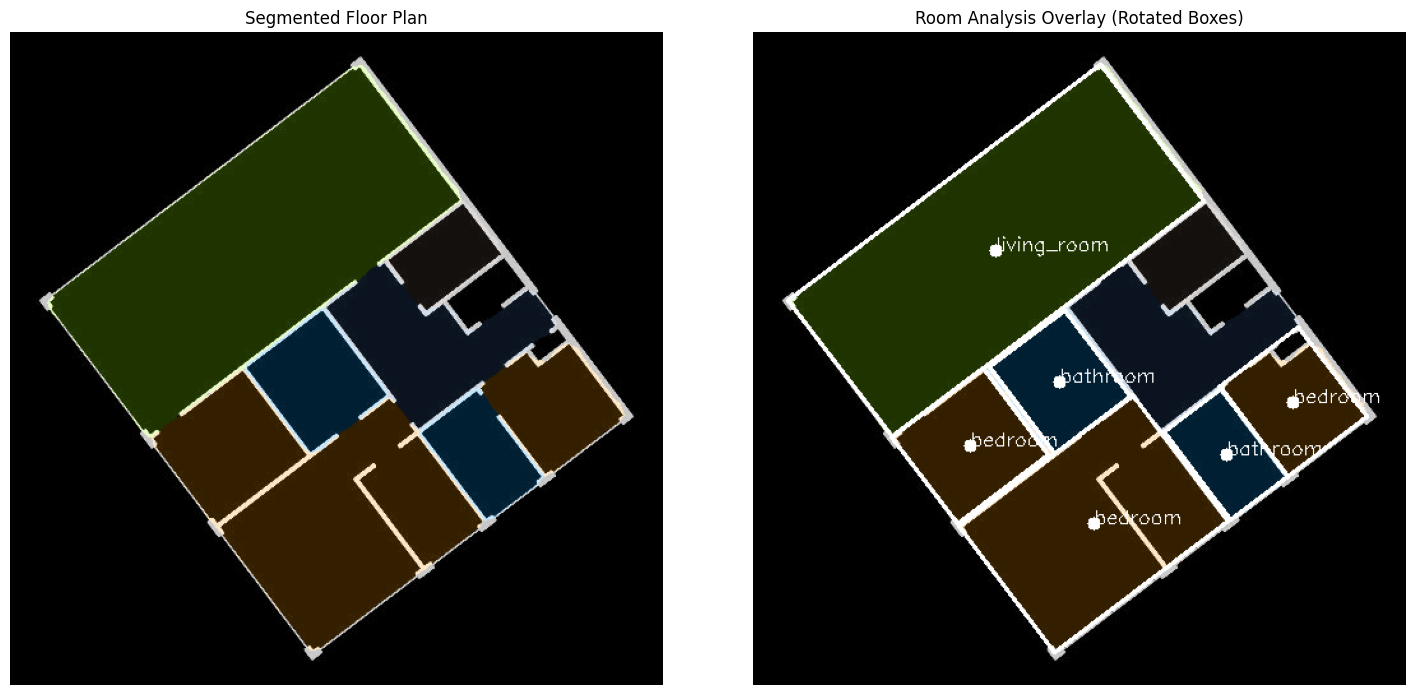

In [ ]:
rooms_data = process_floor_plan('/content/segmented_image_overlay.png', pixel_to_meter_ratio=0.1)